# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

**Choosing to use Q1_clean data. It is essentially the same as the airbnb_hw.csv, minus a couple columns. Many of the columns in airbnb_hw.csv would need to be dropped anyway, so this cleaner and easier to understand data set serves the same purpose.**

**Note: I worked with Aidan, Ian, and Rameez on parts of this lab, but am submitting separately, as I wanted to get more practice with linear models**

In [37]:
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split

1. Clean the data and perform some EDA and visualization to get to know the data set.

In [38]:
df = pd.read_csv("../data/Q1_clean.csv")
df = df.rename(columns = {'Neighbourhood ' : "Neighbourhood"})
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


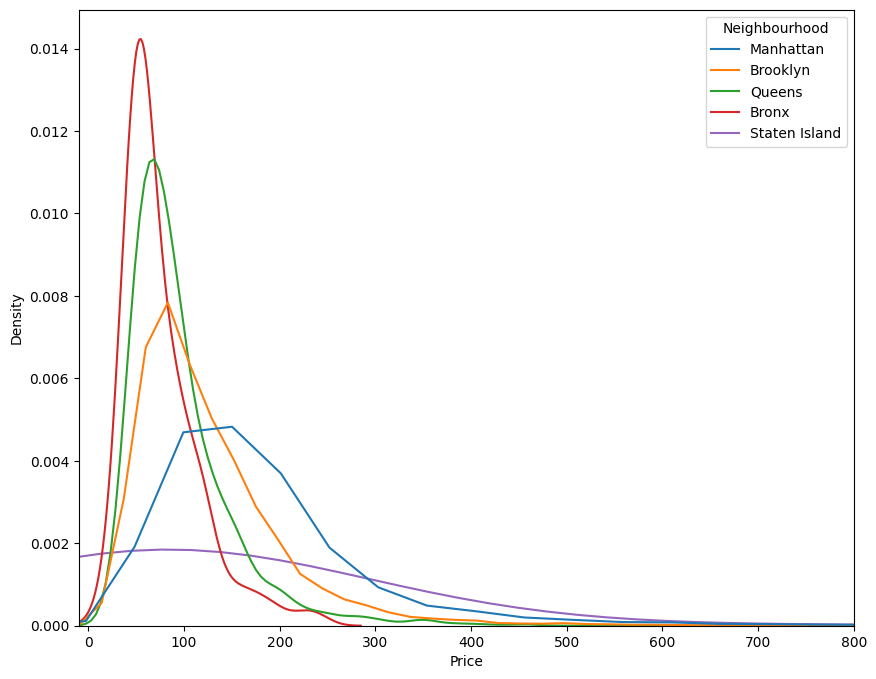

In [39]:
plt.figure(figsize = (10, 8))
sns.kdeplot(data = df, x = "Price", hue = "Neighbourhood", common_norm = False)
plt.xlim(-10, 800)
plt.show()

/tmp/ipykernel_35830/3842877526.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data = df, x = "Price", hue = "Property Type", common_norm = False)


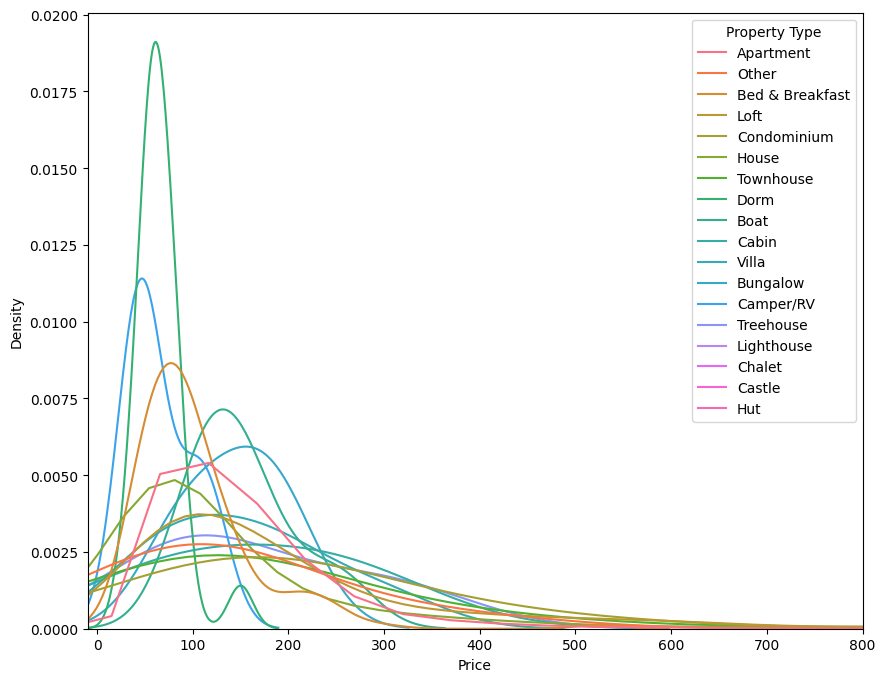

In [40]:
plt.figure(figsize = (10, 8))
sns.kdeplot(data = df, x = "Price", hue = "Property Type", common_norm = False)
plt.xlim(-10, 800)
plt.show()

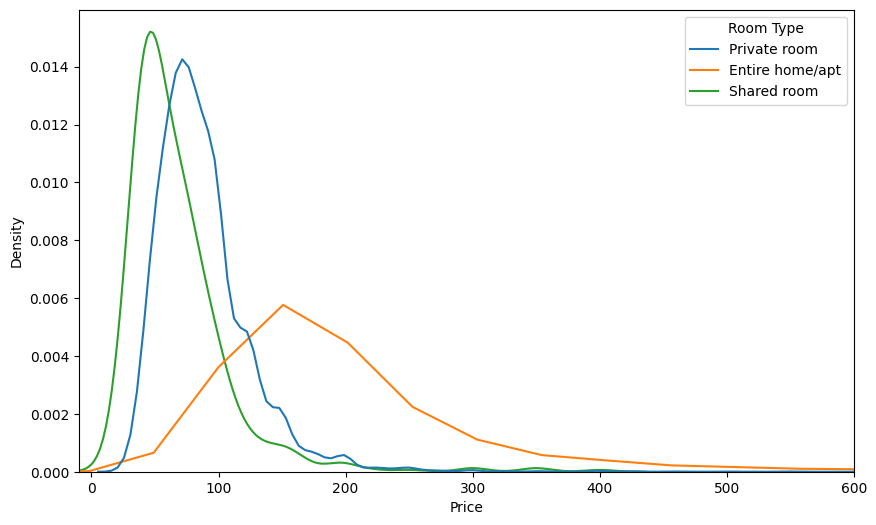

In [41]:
plt.figure(figsize = (10, 6))
sns.kdeplot(data = df, x = "Price", hue = "Room Type", common_norm = False)
plt.xlim(-10, 600)
plt.show()

In [42]:
df.iloc[:, 0:2].agg(["min", "max", "median", "mean"]).transpose()

,min,max,median,mean
Price,10.0,10000.0,125.0,154.787388
Review Scores Rating,20.0,100.0,94.0,91.993093


In [43]:
df["Neighbourhood"].value_counts(dropna = False).reset_index().head(100)

,Neighbourhood,count
0,Manhattan,11763
1,Brooklyn,8487
2,Queens,1590
3,Bronx,217
4,Staten Island,96


In [44]:
df["Property Type"].value_counts(dropna = False).reset_index().head(100)

,Property Type,count
0,Apartment,19656
1,House,1559
2,Loft,591
3,Bed & Breakfast,136
4,Townhouse,83
5,Condominium,48
6,Other,28
7,Dorm,22
8,Boat,6
9,Villa,6


In [45]:
df["Room Type"].value_counts(dropna = False).reset_index().head()

,Room Type,count
0,Entire home/apt,12883
1,Private room,8728
2,Shared room,542


2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.

In [46]:
dummies = pd.get_dummies(df[["Neighbourhood", "Room Type", "Property Type"]], dtype = "int", drop_first = False)
X = pd.concat([df["Review Scores Rating"], dummies], axis = 1)
y = df["Price"]

# Note:
# Review Scores = X.iloc[:, 0]
# Neighbourhoods = X.iloc[:, 1:6]
# Room Type = X.iloc[:, 6:9]
# Property Type = X.iloc[:, 9:]

# Also Note:
# First dummy is not dropped here. It will either need to be drooped in the model, or the intercept can't be fit

3. Implement an ~80/~20 train-test split. Put the test data aside.

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 5)

print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (17722, 27)
X_test shape:  (4431, 27)
y_train shape:  (17722,)
y_test shape:  (4431,)


4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?

In [48]:
# Note:
# Review Scores = X.iloc[:, 0]
# Neighbourhoods = X.iloc[:, 1:6]
# Room Type = X.iloc[:, 6:9]
# Property Type = X.iloc[:, 9:]

train_features = {
    'Review Scores' : X_train.iloc[:, 0],
    "Neighbourhoods" : X_train.iloc[:, 1:6],
    "Room Type" : X_train.iloc[:, 6:9],
    "Property Type" : X_train.iloc[:, 9:]
}

test_features = {
    'Review Scores' : X_test.iloc[:, 0],
    "Neighbourhoods" : X_test.iloc[:, 1:6],
    "Room Type" : X_test.iloc[:, 6:9],
    "Property Type" : X_test.iloc[:, 9:]
}

combos = []
for i in range(1, len(list(train_features.keys())) + 1):
    combos.extend(itertools.combinations(list(train_features.keys()), i))

results = []
for combo in combos:
    
    features_train = pd.concat([train_features[train_feature] for train_feature in combo], axis = 1)
    
    reg = LinearRegression(fit_intercept = False).fit(features_train, y_train)

    features_test = pd.concat([test_features[test_feature] for test_feature in combo], axis = 1)

    results.append({'Features' : combo, 'Train R^2' : reg.score(features_train, y_train), 'Train RMSE' :  round(np.sqrt(np.mean((y_train - reg.predict(features_train))**2)), 4),'Test R^2' : reg.score(features_test, y_test), 'Test RMSE' :  round(np.sqrt(np.mean((y_test - reg.predict(features_test))**2)), 4)})

results_df = pd.DataFrame(results)
results_df.sort_values(by = "Test R^2", ascending = False).head(20)

,Features,Train R^2,Train RMSE,Test R^2,Test RMSE
14,"(Review Scores, Neighbourhoods, Room Type, Pro...",0.177601,139.0540,0.241074,112.6446
13,"(Neighbourhoods, Room Type, Property Type)",0.176393,139.1561,0.237663,112.8975
10,"(Review Scores, Neighbourhoods, Room Type)",0.165261,140.0934,0.226669,113.7086
7,"(Neighbourhoods, Room Type)",0.164077,140.1927,0.223300,113.9561
12,"(Review Scores, Room Type, Property Type)",0.149361,141.4213,0.199007,115.7245
9,"(Room Type, Property Type)",0.148541,141.4895,0.196431,115.9104
5,"(Review Scores, Room Type)",0.143017,141.9477,0.192935,116.1622
2,"(Room Type,)",0.142127,142.0215,0.190144,116.3630
11,"(Review Scores, Neighbourhoods, Property Type)",0.055275,149.0373,0.084232,123.7381
8,"(Neighbourhoods, Property Type)",0.051850,149.3072,0.076806,124.2388


**The model which performs best uses all the features: neighbourhoods, room type, property type, and review scores. It is followed closely by the model that doesn't include review scores. Of note, the drop off in R^2 begins once room type is not included as a feature, indicating it is the most important variable in predicting price.**

5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities? 

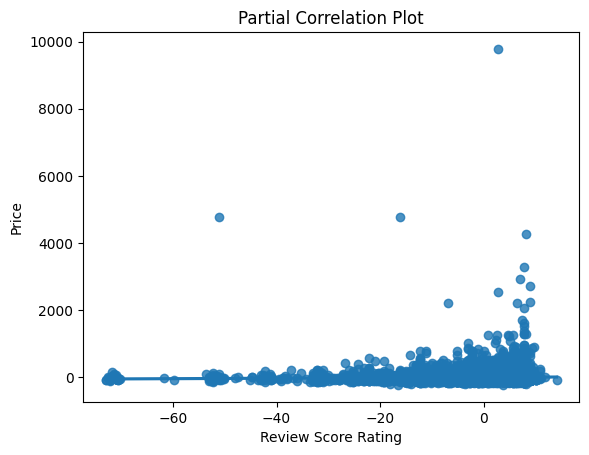

In [49]:
X_k = X["Review Scores Rating"]
X_mk = X.drop("Review Scores Rating", axis = 1)
y = df["Price"]

# Regress y on x_mk, residuals are r_y
reg_y = LinearRegression(fit_intercept = False).fit(X_mk, y)
r_y = y - reg_y.predict(X_mk)

# Regress x_k on x_mk, residuals are r_X
reg_x = LinearRegression(fit_intercept = False).fit(X_mk, X_k)
r_x = X_k - reg_x.predict(X_mk)

sns.regplot(y=r_y, x=r_x).set(title='Partial Correlation Plot')
plt.xlabel("Review Score Rating")
plt.ylabel("Price")
plt.show()

**Yes, there is some non-linearity**

6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?

In [50]:
X_dummies = pd.get_dummies(df[["Neighbourhood", "Property Type", "Room Type"]], dtype = "int", drop_first = True)
X1 = pd.concat([df["Review Scores Rating"], X_dummies], axis = 1)

# Adds squared terms and interactions between features
expander = PolynomialFeatures(degree = 2, include_bias = False)
Z = expander.fit_transform(X1.iloc[:, :])
names = expander.get_feature_names_out()

X = pd.DataFrame(data = Z, columns = names)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 5)

reg = LinearRegression(fit_intercept = True).fit(X_train, y_train)
results = pd.DataFrame({'variable' : reg.feature_names_in_, 'coefficient' : reg.coef_})

y_pred_train = reg.predict(X_train)
y_pred_test = reg.predict(X_test)
train_rmse = np.sqrt(np.mean((y_train - y_pred_train) ** 2))
test_rmse = np.sqrt(np.mean((y_test - y_pred_test) ** 2))

print("Train RMSE: ", round(train_rmse, 4))
print("R-Squared on Train: ", round(reg.score(X_train, y_train), 4))
print()
print("Test RMSE: ", round(test_rmse, 4))
print("R-Squared on Test: ", round(reg.score(X_test, y_test), 4))
print()
print("Best Simple Model Train RMSE: ", round(results_df.sort_values(by = "Train R^2", ascending = False).iloc[0, 2], 4))
print("Best Simple Model Train R^2: ", round(results_df.sort_values(by = "Train R^2", ascending = False).iloc[0, 1], 4))
print()
print("Best Simple Model Test RMSE: ", round(results_df.sort_values(by = "Test R^2", ascending = False).iloc[0, 4], 4))
print("Best Simple Model Test R^2: ", round(results_df.sort_values(by = "Test R^2", ascending = False).iloc[0, 3], 4))

Train RMSE:  135.6403
R-Squared on Train:  0.2175

Test RMSE:  112.2396
R-Squared on Test:  0.2465

Best Simple Model Train RMSE:  139.054
Best Simple Model Train R^2:  0.1776

Best Simple Model Test RMSE:  112.6446
Best Simple Model Test R^2:  0.2411


**The more complex model performs much better than some of the simpler models, but compared to the best of the "simple" models, the difference in performance ranges from negligible to small depending on the randoms state.**

7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?

**In the lab, we analyzed how features of Airbnb listings impacted their prices using hedonic pricing models. After we cleaned the dataset and encoded categorical variables such as neighborhood, property type, and room type, we built several simple linear regression models and evaluated them using RMSE and R² on both training and test sets. When we used models that utilized a single variable, it often underfit the data, whereas the combined model with all features performed better overall. We then built a more complex model with interactions and transformations, which showed improved performance over many of the simpler models. What we found however, when comparing it to the best-performing simple model, the improvement was often marginal, and in some cases negligible, depending on the random state used for the train-test split. This suggested that while complexity can help, it does not always lead to an increase predictive power and may introduce sensitivity to data variation. This lab allowed us to learn how overfitting and underfitting can present itself in real data, and how significant careful model selection and validation are for building models that generalize well.**


8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class

In [51]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

X_full = pd.get_dummies(df[['Neighbourhood', 'Property Type', 'Room Type', 'Review Scores Rating']], drop_first=True)
y = df['Price']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
lasso = LassoCV(cv=5, random_state=0)
lasso.fit(X_train, y_train)

y_train_pred = lasso.predict(X_train)
y_test_pred = lasso.predict(X_test)


train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)


test_r2 = r2_score(y_test, y_test_pred)

print("Lasso selected", np.sum(lasso.coef_ != 0), "features.")
print("Train RMSE:", round(train_rmse, 2), "Test RMSE:", round(test_rmse, 2))
print("Train R²:", round(train_r2, 3), "Test R²:", round(test_r2, 3))


selected_features = pd.Series(lasso.coef_, index=X_full.columns)
selected_features = selected_features[selected_features != 0].sort_values(ascending=False)

print("\n \nSelected Features by Lasso:")
print(selected_features)

Lasso selected 24 features.
Train RMSE: 135.35 Test RMSE: 129.66
Train R²: 0.185 Test R²: 0.192

 
Selected Features by Lasso:
Neighbourhood_Manhattan          38.361910
Neighbourhood_Brooklyn           13.533702
Property Type_House              12.765031
Property Type_Loft               12.091796
Review Scores Rating              6.922096
Property Type_Other               3.051210
Property Type_Townhouse           2.186673
Property Type_Condominium         1.964099
Property Type_Bed & Breakfast     1.798224
Neighbourhood_Queens              1.244599
Property Type_Treehouse           1.131372
Property Type_Villa               1.102931
Property Type_Cabin               0.426498
Property Type_Bungalow            0.218611
Property Type_Castle              0.174200
Property Type_Chalet              0.166237
Property Type_Dorm                0.160956
Property Type_Boat               -0.064854
Property Type_Hut                -0.380409
Neighbourhood_Staten Island      -0.683821
Property Type